In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv('../dataset/tfidf_norm1.csv')

print(df.shape)
df.head()

(756, 3332)


,0312,0530,10,100,10000,1000000,1015,10200,10400,1049,...,yq,yth,yuk,yutub,ywd,zaini,zaman,zoom,zoomin,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.268024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [4]:
X = df.drop(columns=['label'])
y = df['label']

print("Jumlah Kata :", X.shape[1])
print("Jumlah data :", X.shape[0])

Jumlah Kata : 3331
Jumlah data : 756


In [5]:
print(y.value_counts())

label
1    378
0    378
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [7]:
svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Training selesai")

Training selesai


In [8]:
import joblib

joblib.dump(
    svm_model,
    'svc_model_norm1.pkl'
)

print("Model berhasil disimpan")

Model berhasil disimpan


Accuracy  : 0.7632
Precision : 0.7416
Recall    : 0.8354
F1-Score  : 0.7857
              precision    recall  f1-score   support

    Objektif       0.79      0.68      0.74        73
   Subjektif       0.74      0.84      0.79        79

    accuracy                           0.76       152
   macro avg       0.77      0.76      0.76       152
weighted avg       0.77      0.76      0.76       152



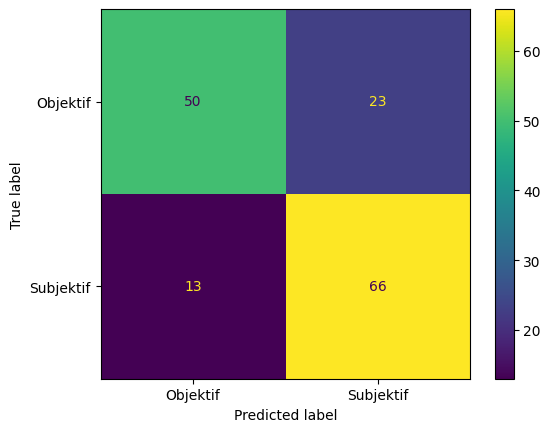

In [9]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Objektif",
            "Subjektif"
        ]
    )
)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Objektif",
        "Subjektif"
    ]
).plot()

plt.show()